In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
# matplotlib.use('TkAgg')  # Alternative: 'Qt5Agg'

/var/folders/kg/2vryh0qs20ncmg9p8d06t7nc0000gn/T/ipykernel_5456/4247020738.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [ ]:
"""
    Plot singularity data:
    1.)  current vs. goal position and highlight 
    2.)  orientation error and highlight 
    3.)  s-value ratios and highlight w/ bars 
    4.)  singular vs. non-singular task torques (single joint) and highlight

    Data: 	
    logger.addToLog(robot_q, "robot_q");
	logger.addToLog(robot_dq, "robot_dq");
	logger.addToLog(ee_pos, "ee_pos");
	logger.addToLog(goal_pos, "goal_pos");
	logger.addToLog(svalues, "svalues");
    logger.addToLog(singular_task_torques, "singular_task_torques");
	logger.addToLog(motion_force_task_torques, "motion_task_torques");
	logger.addToLog(alpha, "alpha");
	logger.addToLog(ori_error, "ori_error");
    logger.addToLog(singular_direction, "singular_direction");
"""

'\n    Plot singularity data:\n    1.)  current vs. goal position and highlight \n    2.)  orientation error and highlight \n    3.)  s-value ratios and highlight w/ bars \n    4.)  Singular vs. non-singular task torques (single joint) + highlight \n\n    Data: \t\n    logger.addToLog(robot_q, "robot_q");\n\tlogger.addToLog(robot_dq, "robot_dq");\n\tlogger.addToLog(ee_pos, "ee_pos");\n\tlogger.addToLog(goal_pos, "goal_pos");\n\tlogger.addToLog(svalues, "svalues");\n    logger.addToLog(singular_task_torques, "singular_task_torques");\n\tlogger.addToLog(motion_force_task_torques, "motion_task_torques");\n\tlogger.addToLog(alpha, "alpha");\n\tlogger.addToLog(ori_error, "ori_error");\n    logger.addToLog(singular_direction, "singular_direction");\n'

In [ ]:
# plot options 
# TYPE_1_OPT = True 
# TYPE_2_OVERHEAD_OPT = False 
# TYPE_2_WRIST_OPT = False 
PLOT_OPT = [1, 0, 0]
YLABELS = ["X (m)", "Y (m)", "Z (m)"]
ORI_YLABELS = ["X (rad)", "Y (rad)", "Z (rad)"]
LABELS = ["Type 1 Singularity", "Type 2 Singularity", "Type 2 Overhead Singularity"]
# START_INDICES = [1500 + 169, 3328, 469]
START_INDICES = [400, 490, 0]
# END_INDICES = [-1, 3328 + 3000, -1]
END_INDICES = [400 + 4600, 490 + 3200, -1]

# csv_file = '../../build/examples/18-panda_singularity/type_1.csv'
# csv_file = './data/03-31/revised-bounds/type_1 copy.csv'
# csv_file = './data/03-31/revised-bounds/type_2_wrist.csv'
# csv_file = './data/03-26/type_2_overhead.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_1.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_2_wrist.csv'
# csv_file = './data/04-08/type_2_wrist_pos.csv'
# csv_file = './data/04-04/type_2_wrist_with_vel.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_2_wrist.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_1.csv'
# csv_file = './data/01-29/type_1.csv'
csv_file = './data/01-29/type_2.csv'
# csv_file = './data/12-30/type_2_wrist.csv'
# csv_file = './data/01-07/type_2_wrist.csv'
# csv_file = './data/01-28/type_1_revised.csv'
# csv_file = './data/01-28/type_2_wrist_revised.csv'
joint_index = 0
exp_index = 0

In [127]:
# s values 
# combined_s_values = [7e-3, 7e-2]
# combined_s_values = [2e-2, 7e-2]
# linear_s_values = [3e-2, 3e-1]
combined_s_values = [5e-2, 5e-2]

In [146]:
# Load CSV file
# def plot(csv_file, joint_index, exp_index):
df = pd.read_csv(csv_file)   

# Drop 'timestamp' column if it exists
if 'timestamp' in df.columns:
    df = df.drop(columns=['timestamp'])  

# Convert 'time' column to float
df['time'] = df['time'].astype(float)  

# Extract data columns 
ee_pos_columns = [col for col in df.columns if 'ee_pos' in col]  
goal_pos_columns = [col for col in df.columns if 'goal_pos' in col]
ori_error_columns = [col for col in df.columns if 'ori_error' in col]
svalue_columns = [col for col in df.columns if 'svalues' in col]
singular_task_torques_columns = [col for col in df.columns if 'singular_task_torques' in col]
motion_task_torques_columns = [col for col in df.columns if 'motion' in col]
alpha_columns = [col for col in df.columns if 'alpha' in col]
non_singular_task_torques_columns = [col for col in df.columns if 'non_singular_task_torques' in col]
joint_strategy_torques_columns = [col for col in df.columns if 'singular_joint_space_torques' in col]
# nonhandling_torque_columns = [col for col in df.columns if 'nonhandling' in col]
nonhandling_torque_columns = [col for col in df.columns if 'unmodified' in col]
evalue_columns = [col for col in df.columns if 'evalues' in col]

# Indices
print('Start index: ', START_INDICES[exp_index])
print('End index: ', END_INDICES[exp_index])

# # Remove zero-values in eigenvectors
# eigen_vec = (df[alpha_columns][START_INDICES[exp_index]:END_INDICES[exp_index]]).to_numpy()
# for i in range(np.shape(eigen_vec)[0]):
#     if (eigen_vec[i] == 0):
#         eigen_vec[i] = 100

# Fill in alpha holes
alpha_vec = (df[alpha_columns][START_INDICES[exp_index]:END_INDICES[exp_index]]).to_numpy()
# for i in range(np.shape(alpha_vec)[0]):
#     if np.isnan(alpha_vec[i]):
#         alpha_vec[i] = 1

s_vec = (df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]]).to_numpy()

svalue_ratios = np.abs(df[evalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy(dtype=np.float64))
# svalue_ratios = np.abs(df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy(dtype=np.float64))
# normalized_matrix = svalue_ratios / svalue_ratios.max(axis=1, keepdims=True)
normalized_matrix = svalue_ratios

# Get indices for when alpha != 1
s_indices = np.where(normalized_matrix[:, -1] < combined_s_values[1])[0] + START_INDICES[exp_index]
# s_indices = np.where(df[alpha_columns][START_INDICES[exp_index]:END_INDICES[exp_index]] != 1)[0] + START_INDICES[exp_index]

# plt.plot(alpha_vec)
# plt.show()

# Debug data
print(np.max(df[singular_task_torques_columns[0]][START_INDICES[exp_index]:END_INDICES[exp_index]]))
print(len(s_indices))
print(combined_s_values[1])
print(s_vec)
print(alpha_vec)

Start index:  400
End index:  5000
6.74995
1828
0.05
[[1.83622  1.80652  0.964928 0.364295 0.293519 0.222224]
 [1.83622  1.80652  0.964927 0.364296 0.293519 0.222224]
 [1.83622  1.80652  0.964932 0.364295 0.293519 0.222224]
 ...
 [1.83292  1.79735  0.979404 0.365544 0.296467 0.221591]
 [1.83292  1.79735  0.979404 0.365544 0.296467 0.221591]
 [1.83292  1.79735  0.979404 0.365544 0.296467 0.221591]]
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]


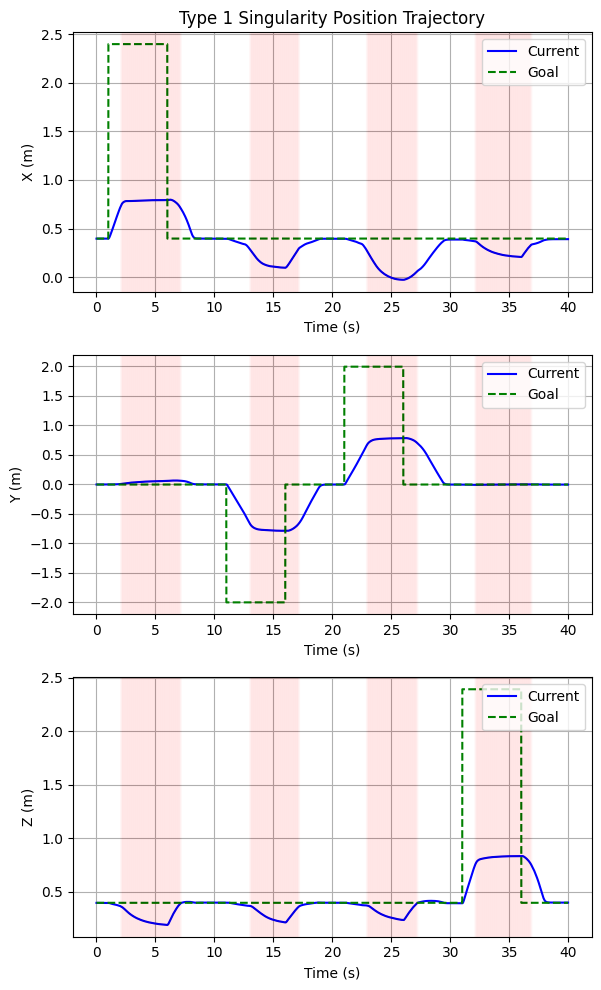

In [129]:
"""
    Plot data 
"""

# Plot ee vs. goal position 
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
for i in range(3):
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                    df[ee_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='b', label='Current')
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                    df[goal_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='g', linestyle='--', label='Goal')

    # Plot vertical yellow bars
    # for j in range(len(s_indices)):
        # if s_indices[j] != 0:
    for j in s_indices:
        axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.005)

    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel(YLABELS[i])
    # axes[i].set_title(LABELS[exp_index])
    # axes[i].legend(loc="lower right")
    # axes[i].legend(loc="upper left")
    axes[i].legend(loc="upper right")
    axes[i].grid() 
    
    # Use range for equal spacing
    goal_val = np.mean(df[goal_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]])
    # if i == 0:
    #     axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    # elif i == 1:
    #     axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    # elif i == 2:
    #     axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])

axes[0].set_title(LABELS[exp_index] + ' Position Trajectory')
plt.tight_layout()
plt.show()

# # Plot ee vs. goal position all in one plot 
# fig, axes = plt.subplots(1, 1, figsize=(10, 10))
# axes.plot(df['time'], df[ee_pos_columns[0]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[0]], color='g', linestyle='--')

# axes.plot(df['time'], df[ee_pos_columns[1]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[1]], color='g', linestyle='--')

# axes.plot(df['time'], df[ee_pos_columns[2]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[2]], color='g', linestyle='--')

# # Plot vertical yellow bars
# # for j in range(len(s_indices)):
#     # if s_indices[j] != 0:
# for i in s_indices:
#     axes.axvline(x=df['time'][i], color='red', linestyle='-', linewidth=5, alpha=0.01)

# axes.set_xlabel('Time (s)')
# axes.set_ylabel(YLABELS[0])
# axes.set_title(LABELS[exp_index])
# axes.legend()
# axes.grid() 

# plt.tight_layout()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


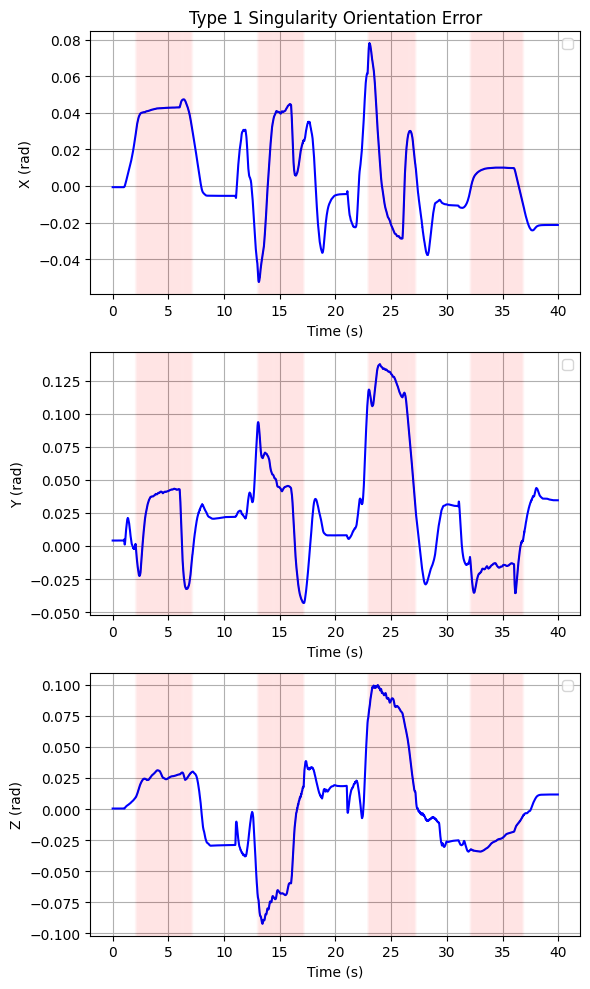

In [130]:
# Plot orientation error 
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
for i in range(3):
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                 df[ori_error_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='b')

    # Plot vertical yellow bars
    # for j in range(len(s_indices)):
        # if s_indices[j] != 0:
        # axes[i].axvline(x=df['time'][s_indices[j]], color='red', linestyle='-', linewidth=5, alpha=0.01)
    for j in s_indices:
        axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.005)

    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel(ORI_YLABELS[i])
    # axes[i].set_title(LABELS[exp_index])
    axes[i].legend()
    axes[i].grid() 

axes[0].set_title(LABELS[exp_index] + ' Orientation Error')

plt.tight_layout()
plt.show()

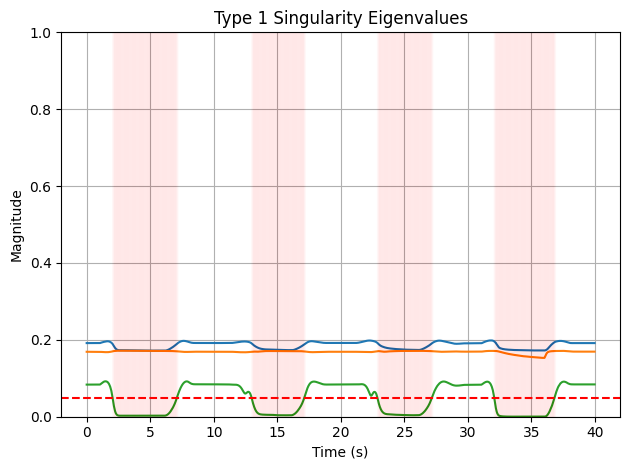

In [155]:
# Plot s value ratios
# svalue_ratios = np.abs(df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy(dtype=np.float64))
# normalized_matrix = svalue_ratios / svalue_ratios.max(axis=1, keepdims=True)

# print(normalized_matrix[0])

# manual fix for type 1 
# normalized_matrix[3262][:] = normalized_matrix[3262 - 1][:]

fig, axes = plt.subplots(1, 1)
t = df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]]
mask = normalized_matrix[:, 0] != 0
# axes.plot(t[mask], normalized_matrix[mask, 0], label="S1")
# axes.plot(t[mask], normalized_matrix[mask, 1], label="S2")
# axes.plot(t[mask], normalized_matrix[mask, 2], label="S3")
axes.plot(t[mask], normalized_matrix[mask, 3], label="S4")
axes.plot(t[mask], normalized_matrix[mask, 4], label="S5")
axes.plot(t[mask], normalized_matrix[mask, 5], label="S6")

for j in s_indices:
    axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.005)

# Draw horizontal dashed lines
# axes.axhline(y=linear_s_values[0], color='red', linestyle='--')
# axes.axhline(y=linear_s_values[1], color='orange', linestyle='--')
axes.axhline(y=combined_s_values[0], color='red', linestyle='--')
# axes.axhline(y=combined_s_values[1], color='orange', linestyle='--')

# Y limits 
axes.set_ylim([0, 1.0])

axes.set_xlabel('Time (s)')
axes.set_ylabel('Magnitude')
# axes.set_title(LABELS[exp_index] + ' Singular Value Ratios')
axes.set_title(LABELS[exp_index] + ' Eigenvalues')
# axes.legend()
axes.grid() 

plt.tight_layout()
plt.show()

0.1030825


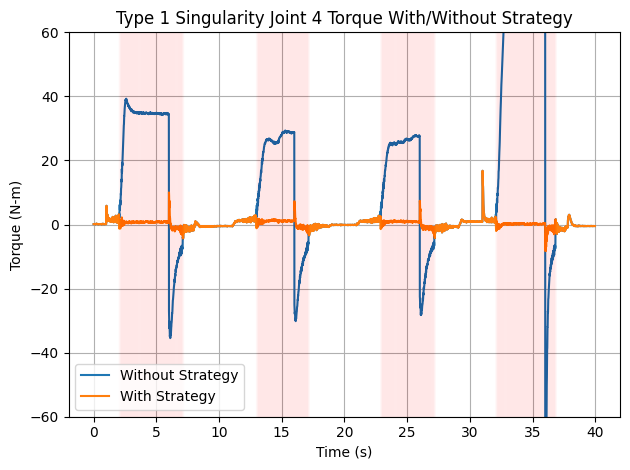

In [151]:
# Plot singular vs. strategy torques for a joint 
joint_index = 3  # type 2 singularity 
# joint_index = 3 # type 1 singularity
# singular_joint_torque = df[singular_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
non_singular_joint_torque = df[non_singular_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
motion_force_joint_torque = df[motion_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
joint_strategy_torque = df[joint_strategy_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
nonhandling_torque = df[nonhandling_torque_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
singular_joint_torque = motion_force_joint_torque - non_singular_joint_torque - joint_strategy_torque
fig, axes = plt.subplots(1, 1)
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], non_singular_joint_torque + nonhandling_torque, label='Without Strategy')
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], motion_force_joint_torque, label='With Strategy')

# Plot vertical yellow bars
# for j in range(len(s_indices)):
    # if s_indices[j] != 0:
    # axes.axvline(x=df['time'][s_indices[j]], color='red', linestyle='-', linewidth=5, alpha=0.01)
for j in s_indices:
    axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.005)

axes.set_xlabel('Time (s)')
axes.set_ylabel('Torque (N-m)')
axes.set_ylim([-60, 60])
axes.set_title(LABELS[exp_index] + ' Joint ' + str(joint_index + 1) + ' Torque With/Without Strategy')
axes.legend(loc='lower left')
axes.grid() 

print(np.max(singular_joint_torque))

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show() 

In [234]:
# Example usage
# plot("./data/type_2_wrist.csv", 0, 0)
# plot("../../build/examples/18-panda_singularity/type_1.csv", 3, 0)
# plot("../../build/examples/18-panda_singularity/type_2_overhead.csv", 0, 0)
# plot("../../build/examples/18-panda_singularity/type_2_wrist.csv", 0, 0)
plot("./data/03-31/revised-bounds/type_2_wrist.csv", 0, 1)
plt.show()

NameError: name 'plot' is not defined